In [2]:
import polars as pl
from pathlib import Path

import sys
print(sys.executable)



c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\Scripts\python.exe


In [3]:
# Load the Knee Replacement Provider data
file_path = r"c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\notebooks\Lalita\UnderstandingData\merged\Knee Replacement Provider.csv"
df = pl.read_csv(file_path, separator=',', infer_schema_length=10000, ignore_errors=True)

# Make a copy of the original dataframe
df_original = df.clone()
print("Original dataframe copied to df_original.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Original dataframe copied to df_original.
Shape: 139,236 rows × 82 columns


In [4]:

# For columns with exactly 2 unique values where one is 9, recode 9 → 0
cols_to_recode = [
    c for c in df.columns
    if set(df[c].drop_nulls().unique().to_list()) == {9, 0}
    or (
        len(df[c].drop_nulls().unique()) == 2
        and 9 in df[c].drop_nulls().unique().to_list()
    )
]

print(f"Columns to recode (2 unique values, one is 9): {cols_to_recode}")

df = df.with_columns([
    pl.when(pl.col(c) == 9).then(0).otherwise(pl.col(c)).alias(c)
    for c in cols_to_recode
])

print("Done. Value 9 replaced with 0 in the above columns.")


Columns to recode (2 unique values, one is 9): ['Heart Disease', 'High Bp', 'Stroke', 'Circulation', 'Lung Disease', 'Diabetes', 'Kidney Disease', 'Nervous System', 'Liver Disease', 'Cancer', 'Depression', 'Arthritis']
Done. Value 9 replaced with 0 in the above columns.


In [5]:
# Recode 'Pre-Op Q Assisted By': 9 → 0, anything else → 1
df = df.with_columns(
    pl.when(pl.col("Pre-Op Q Assisted By") == 9)
      .then(0)
      .otherwise(1)
      .alias("Pre-Op Q Assisted By")
)

print("'Pre-Op Q Assisted By' recoded: 9 → 0, all other values → 1")
print(df["Pre-Op Q Assisted By"].value_counts())

#Post-Op Q Assisted By 

df = df.with_columns(
    pl.when(pl.col("Post-Op Q Assisted By") == 9)
      .then(0)
      .otherwise(1)
      .alias("Post-Op Q Assisted By")
)

print("'Post-Op Q Assisted By' recoded: 9 → 0, all other values → 1")
print(df["Post-Op Q Assisted By"].value_counts())


'Pre-Op Q Assisted By' recoded: 9 → 0, all other values → 1
shape: (1, 2)
┌──────────────────────┬────────┐
│ Pre-Op Q Assisted By ┆ count  │
│ ---                  ┆ ---    │
│ i32                  ┆ u32    │
╞══════════════════════╪════════╡
│ 1                    ┆ 139236 │
└──────────────────────┴────────┘
'Post-Op Q Assisted By' recoded: 9 → 0, all other values → 1
shape: (2, 2)
┌───────────────────────┬────────┐
│ Post-Op Q Assisted By ┆ count  │
│ ---                   ┆ ---    │
│ i32                   ┆ u32    │
╞═══════════════════════╪════════╡
│ 1                     ┆ 10864  │
│ 0                     ┆ 128372 │
└───────────────────────┴────────┘


In [6]:

# Column types and missing value analysis
# Missing values considered: NaN/null, '', '*', 999

MISSING_SENTINELS_STR = {'*', ''}
MISSING_SENTINELS_NUM = {999, 9}

def count_missing_pl(df: pl.DataFrame, col: str) -> int:
    series = df[col]
    null_count = int(series.is_null().sum())
    if series.dtype in (pl.Utf8, pl.String):
        sentinel_count = int(series.drop_nulls().is_in(list(MISSING_SENTINELS_STR)).sum())
    else:
        sentinel_count = int(series.drop_nulls().is_in(list(MISSING_SENTINELS_NUM)).sum())
    return null_count + sentinel_count

rows, cols_count = df.shape

missing_info = pl.DataFrame({
    'column':        df.columns,
    'dtype':         [str(df[c].dtype) for c in df.columns],
    'total_rows':    [rows] * cols_count,
    'missing_count': [count_missing_pl(df, c) for c in df.columns],
}).with_columns(
    (pl.col('missing_count') / pl.col('total_rows') * 100).round(2).alias('missing_%')
).sort('missing_%', descending=True)

print(f"Dataset shape: {rows:,} rows × {cols_count} columns")

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=10000):
    print(f"\nColumns with missing values (NaN, '', '*', 999):\n")
    print(missing_info.filter(pl.col('missing_count') > 0))
    print(f"\n--- All columns ---\n")
    print(missing_info)


Dataset shape: 139,236 rows × 82 columns

Columns with missing values (NaN, '', '*', 999):

shape: (61, 5)
┌─────────────────────────────────┬─────────┬────────────┬───────────────┬───────────┐
│ column                          ┆ dtype   ┆ total_rows ┆ missing_count ┆ missing_% │
│ ---                             ┆ ---     ┆ ---        ┆ ---           ┆ ---       │
│ str                             ┆ str     ┆ i64        ┆ i64           ┆ f64       │
╞═════════════════════════════════╪═════════╪════════════╪═══════════════╪═══════════╡
│ Knee Replacement EQ VAS_Post-O… ┆ Float64 ┆ 139236     ┆ 19423         ┆ 13.95     │
│ Post-Op Q Bleeding              ┆ Int64   ┆ 139236     ┆ 17138         ┆ 12.31     │
│ Post-Op Q Urine                 ┆ Int64   ┆ 139236     ┆ 15534         ┆ 11.16     │
│ Post-Op Q Wound                 ┆ Int64   ┆ 139236     ┆ 14740         ┆ 10.59     │
│ Knee Replacement EQ 5D Index P… ┆ Float64 ┆ 139236     ┆ 14322         ┆ 10.29     │
│ Pre-Op Q EQ VAS      

In [7]:

# Create 'has_missing' flag: 1 if any value in that row is missing across any column, 0 otherwise
def is_missing_series(series: pl.Series) -> pl.Series:
    if series.dtype in (pl.Utf8, pl.String):
        return series.is_null() | series.is_in(['', '*'])
    else:
        return series.is_null() | series.is_in([999])

any_missing_flag = pl.Series("has_missing", [False] * df.shape[0])
for c in df.columns:
    any_missing_flag = any_missing_flag | is_missing_series(df[c])

df = df.with_columns(
    any_missing_flag.cast(pl.Int8).alias("has_missing")
)

print("'has_missing' column added (1 = at least one missing value in that row, 0 = complete row).")
print(df["has_missing"].value_counts().sort("has_missing"))


'has_missing' column added (1 = at least one missing value in that row, 0 = complete row).
shape: (2, 2)
┌─────────────┬────────┐
│ has_missing ┆ count  │
│ ---         ┆ ---    │
│ i8          ┆ u32    │
╞═════════════╪════════╡
│ 0           ┆ 103486 │
│ 1           ┆ 35750  │
└─────────────┴────────┘


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due t

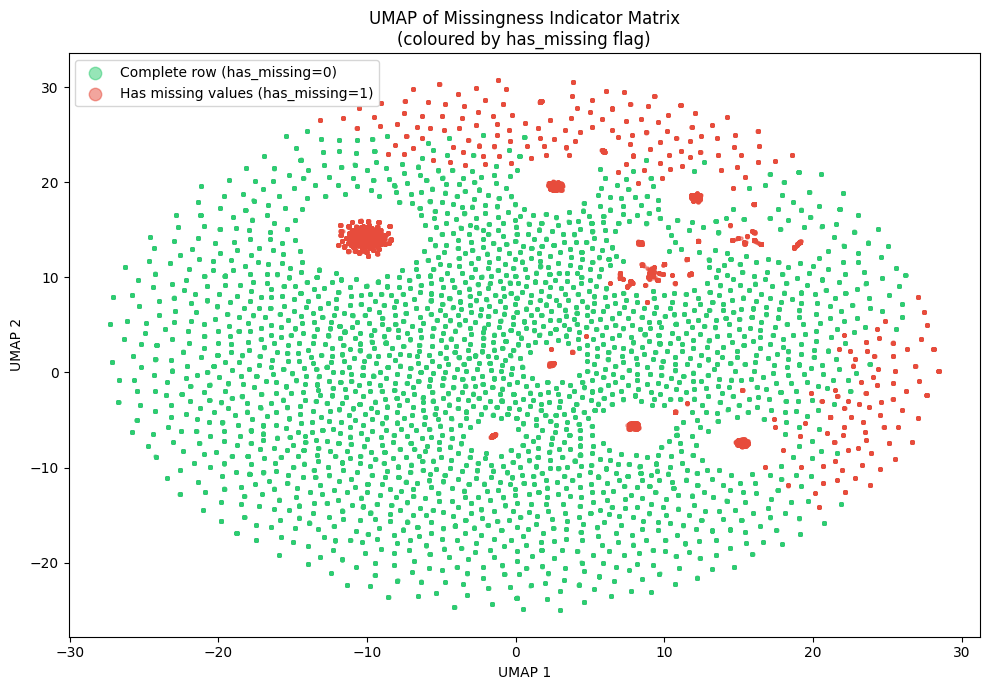

In [9]:

# UMAP view of missingness patterns — coloured by has_missing flag
# umap was just installed, restart the kernel first (Kernel > Restart)
from umap import UMAP
import matplotlib.pyplot as plt
import numpy as np

# Build binary missingness indicator matrix (1 = missing, 0 = present) for all columns
def is_missing_np(series: pl.Series) -> np.ndarray:
    if series.dtype in (pl.Utf8, pl.String):
        return (series.is_null() | series.is_in(['', '*'])).to_numpy().astype(np.uint8)
    else:
        return (series.is_null() | series.is_in([999])).to_numpy().astype(np.uint8)

miss_matrix = np.column_stack([is_missing_np(df[c]) for c in df.columns if c != "has_missing"])

# Subsample to max 5000 rows for speed (UMAP can be slow on large datasets)
MAX_ROWS = 500000000
n_rows = miss_matrix.shape[0]
if n_rows > MAX_ROWS:
    rng = np.random.default_rng(42)
    idx = rng.choice(n_rows, MAX_ROWS, replace=False)
    X_plot = miss_matrix[idx]
    labels = df["has_missing"].to_numpy()[idx]
    print(f"Subsampled to {MAX_ROWS:,} rows for UMAP.")
else:
    X_plot = miss_matrix
    labels = df["has_missing"].to_numpy()

# Fit UMAP
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_plot)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
for val, label, color in [(0, 'Complete row (has_missing=0)', '#2ecc71'),
                           (1, 'Has missing values (has_missing=1)', '#e74c3c')]:
    mask = labels == val
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=color, label=label, s=5, alpha=0.5)

ax.set_title("UMAP of Missingness Indicator Matrix\n(coloured by has_missing flag)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()


In [ ]:

# Imputation strategy suggestion for each column with missing values
# Rules:
#   missing > 50%       → consider DROPPING the column
#   string/categorical  → MODE imputation
#   numeric, skewed     → MEDIAN imputation  (|skew| > 1)
#   numeric, symmetric  → MEAN imputation
#   binary (2 values)   → MODE imputation

import scipy.stats as stats

def suggest_imputation(df: pl.DataFrame, col: str, missing_pct: float) -> dict:
    series = df[col].drop_nulls()
    
    # filter out sentinels before profiling
    if series.dtype in (pl.Utf8, pl.String):
        series = series.filter(~series.is_in(['', '*']))
    else:
        series = series.filter(~series.is_in([999]))

    n_unique = series.n_unique()
    dtype = str(df[col].dtype)

    if missing_pct > 50:
        strategy = "⚠️  DROP column (>50% missing)"
        detail = f"{missing_pct:.1f}% missing"
    elif series.dtype in (pl.Utf8, pl.String):
        mode_val = series.mode().to_list()
        strategy = "MODE (categorical)"
        detail = f"mode = {mode_val[0] if mode_val else 'N/A'}"
    elif n_unique == 2:
        mode_val = series.mode().to_list()
        strategy = "MODE (binary)"
        detail = f"mode = {mode_val[0] if mode_val else 'N/A'}"
    else:
        arr = series.to_numpy()
        skewness = stats.skew(arr)
        median_val = float(series.median())
        mean_val   = float(series.mean())
        if abs(skewness) > 1:
            strategy = "MEDIAN (skewed numeric)"
            detail = f"skew={skewness:.2f}, median={median_val:.2f}"
        else:
            strategy = "MEAN (symmetric numeric)"
            detail = f"skew={skewness:.2f}, mean={mean_val:.2f}"

    return {"column": col, "dtype": dtype, "missing_%": round(missing_pct, 2),
            "n_unique": n_unique, "suggestion": strategy, "detail": detail}

# Build suggestion table for columns that have missing values
suggestions = []
for row in missing_info.filter(pl.col("missing_count") > 0).iter_rows(named=True):
    col = row["column"]
    if col == "has_missing":
        continue
    suggestions.append(suggest_imputation(df, col, row["missing_%"]))

suggestion_df = pl.DataFrame(suggestions)

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=12000, fmt_str_lengths=80):
    print("=== Imputation Strategy Suggestions ===\n")
    print(suggestion_df)


In [18]:

# Save to parquet in UnderstandingData/output/
output_dir = Path(r"c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\notebooks\Lalita\UnderstandingData\output")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "knee_replacement_providerStep1.parquet"
df.write_parquet(output_path)

print(f"Saved to: {output_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Saved to: c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\notebooks\Lalita\UnderstandingData\output\knee_replacement_providerStep1.parquet
Shape: 139,236 rows × 82 columns
